In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import quad

In [2]:
def basic_P1(x, i, h):
    return np.piecewise(
        x,
        [(x >= (i - 1) * h) & (x < i * h), (x >= i * h) & (x < (i + 1) * h)],
        [lambda x: 1 - i + x / h, lambda x: 1 + i - x / h, lambda x: 0.0],
    )


def N0(ksi):
    return 0.5 - 0.5 * ksi


def N1(ksi):
    return 0.5 + 0.5 * ksi


def phi(ksi, omega):
    a = omega.global_coordinates[0]
    b = omega.global_coordinates[1]
    return N0(ksi) * a + N1(ksi) * b


def dN0(ksi):
    return -0.5


def dN1(ksi):
    return 0.5


def J(omega):
    return (omega.global_coordinates[1] - omega.global_coordinates[0]) / 2.0


def J_inv(omega):
    return 2.0 / (omega.global_coordinates[1] - omega.global_coordinates[0])


def u_analytic(x):
    return np.sin(x)


def f(x):
    return -np.sin(x)


def x_of_ksi(ksi, omega):
    return N0(ksi) * omega.global_coordinates[0] + N1(ksi) * omega.global_coordinates[1]


def ksi_of_x(x, omega):
    a = omega.global_coordinates[0]
    b = omega.global_coordinates[1]

    return ((a + b) - 2 * x) / (a - b)


def uh_at_points(points_list, elements_list, u):
    values_list = np.zeros_like(points_list)
    for i, x in enumerate(points_list):
        for element in elements_list:
            if element.global_coordinates[0] <= x <= element.global_coordinates[1]:
                ia, ib = element.global_indexes
                ua, ub = u[ia], u[ib]

                ksi = ksi_of_x(x, element)

                values_list[i] = N0(ksi) * ua + N1(ksi) * ub
    return values_list

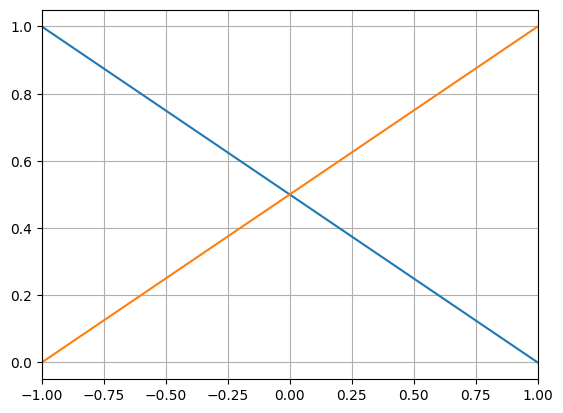

In [3]:
reference_domain = np.linspace(-1.0, 1.0, 2, endpoint=True)
reference_domain

plt.figure()
plt.xlim(reference_domain[0], reference_domain[-1])
plt.grid()

plt.plot(reference_domain, N0(reference_domain))
plt.plot(reference_domain, N1(reference_domain))

In [4]:
class Omega:
    def __init__(self, global_coordinates, global_indexes):
        self.global_coordinates = global_coordinates
        self.global_indexes = global_indexes

In [5]:
a = 0.0
b = 2.0

u_left = u_analytic(a)
u_right = u_analytic(b)

num_global_nodes = 5
num_local_nodes = 2
x_domain = np.linspace(a, b, num_global_nodes, endpoint=True)

elements_list = [Omega([x_domain[i], x_domain[i + 1]], [i, i + 1]) for i in range(x_domain.size - 1)]

for element in elements_list:
    k11 = quad(
        lambda ksi: dN0(ksi) * dN0(ksi) * J_inv(element) ** 2 * J(element),
        -1.0,
        1.0,
    )[0]
    k12 = quad(
        lambda ksi: dN0(ksi) * dN1(ksi) * J_inv(element) ** 2 * J(element),
        -1.0,
        1.0,
    )[0]
    k21 = quad(
        lambda ksi: dN1(ksi) * dN0(ksi) * J_inv(element) ** 2 * J(element),
        -1.0,
        1.0,
    )[0]
    k22 = quad(
        lambda ksi: dN1(ksi) * dN1(ksi) * J_inv(element) ** 2 * J(element),
        -1.0,
        1.0,
    )[0]

    element.K = np.array([[k11, k12], [k21, k22]])

    f1 = quad(lambda ksi: -f(x_of_ksi(ksi, element)) * N0(ksi) * J(element), -1, 1)[0]
    f2 = quad(lambda ksi: -f(x_of_ksi(ksi, element)) * N1(ksi) * J(element), -1, 1)[0]

    element.F = np.array([f1, f2])

global_K = np.zeros((num_global_nodes, num_global_nodes))
global_F = np.zeros(num_global_nodes)

for element in elements_list:
    for i in range(num_local_nodes):
        global_F[element.global_indexes[i]] += element.F[i]
        for j in range(num_local_nodes):
            global_K[element.global_indexes[i], element.global_indexes[j]] += element.K[i, j]

display(global_K)
display(global_F)

array([[ 2., -2.,  0.,  0.,  0.],
       [-2.,  4., -2.,  0.,  0.],
       [ 0., -2.,  4., -2.,  0.],
       [ 0.,  0., -2.,  4., -2.],
       [ 0.,  0.,  0., -2.,  2.]])

array([0.04114892, 0.23476018, 0.41204289, 0.48844312, 0.23975172])

In [6]:
dirichlet_nodes = np.array([0, num_global_nodes - 1])

rhs_K = global_K[:, dirichlet_nodes]
rhs_u = np.array((u_left, u_right))
rhs = rhs_K @ rhs_u
global_F -= rhs

global_K_reduced = global_K[1 : num_global_nodes - 1, 1 : num_global_nodes - 1]
global_F_reduced = global_F[1 : num_global_nodes - 1]

In [7]:
u = np.zeros(num_global_nodes)
u_free = np.linalg.solve(global_K_reduced, global_F_reduced)
u[0] = u_left
u[1:-1] = u_free
u[-1] = u_right

u_exact = u_analytic(x_domain)
diff_norm = np.linalg.norm(u_exact - u)
diff_norm

np.float64(1.2412670766236366e-16)

In [8]:
def error_L2():
    gauss_xi = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)])
    gauss_w  = np.array([5/9, 8/9, 5/9])

    l2_sq = 0.0

    for e in range(len(elements_list)):
        element = elements_list[e]
        ia, ib = element.global_indexes
        ua, ub = u[ia], u[ib]
        J_e = J(element)

        for ksi, w in zip(gauss_xi, gauss_w):
            x = x_of_ksi(ksi, element)
            uh = N0(ksi)*ua + N1(ksi)*ub
            ue = u_analytic(x)
            l2_sq += w * (uh - ue)**2 * J_e

    l2_err = np.sqrt(l2_sq)
    return l2_err

l2_err = error_L2()
print("L2 error =", l2_err)

L2 error = 0.024835118313973843


In [9]:
plot_domain = np.linspace(a, b, 1000, endpoint=True)
u_at_points = uh_at_points(plot_domain, elements_list, u)
u_exact_at_points = u_analytic(plot_domain)

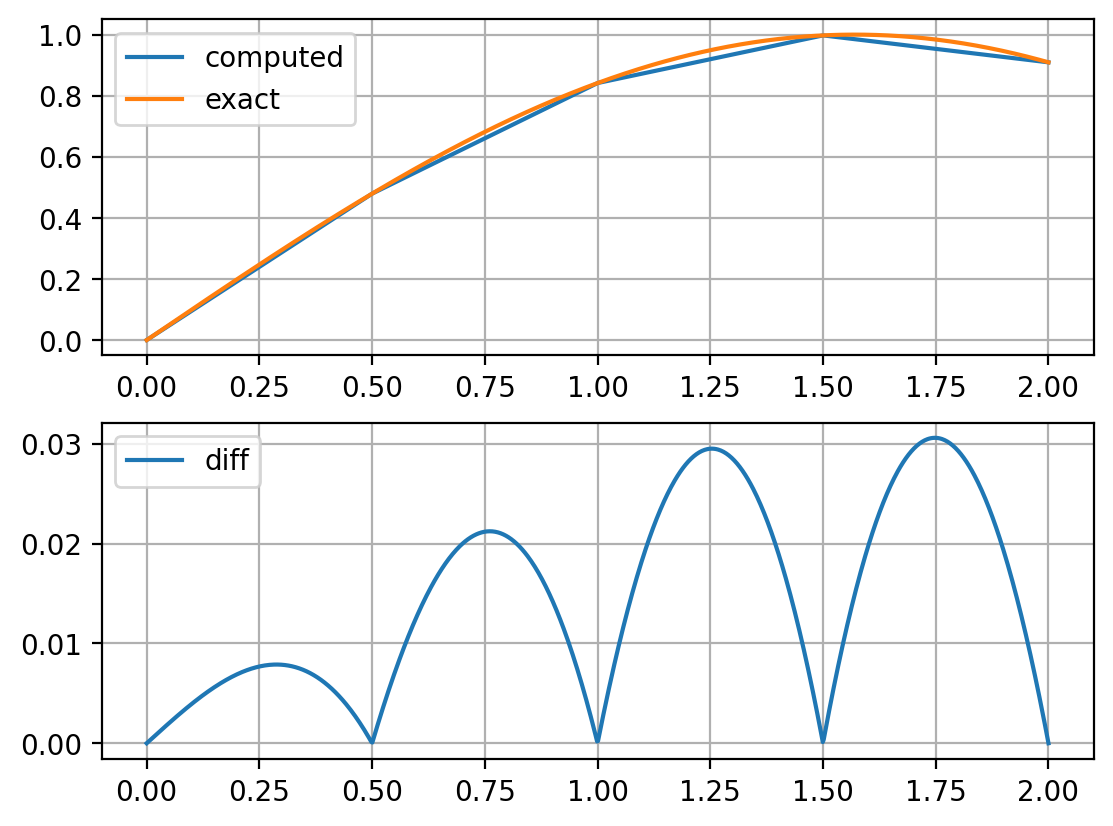

In [10]:
fig, ax = plt.subplots(2, 1, dpi=200)
ax[0].plot(plot_domain, u_at_points, label="computed")
ax[0].plot(plot_domain, u_exact_at_points, label="exact")
ax[1].plot(plot_domain, u_exact_at_points - u_at_points, label="diff")

ax[0].grid()
ax[1].grid()

ax[0].legend()
ax[1].legend()